# Quantitative Momentum — Implementation Comparison

Loads trades from `results/quantitative_momentum_trades.csv` (winning variant from backtest).

**Architecture:** Portfolio-level (~25 names per rebalance, value-weighted by entry mktcap). Unlike per-instrument strategies (IBS, Donchian), QM's allocation is determined at the signal level — value-weighting is intrinsic, not a sizing choice. So Implementation focuses on **portfolio-level leverage** rather than per-trade sizing.

**Sizing variants:**
- Simple bet at varying leverage levels (1×, 1.5×, 2×, 3×)
- Comparison vs SPY at matched drawdown (does QM add value beyond what leverage alone could achieve?)

**Note:** Risk-based and Kelly are not meaningful for QM:
- Risk-based requires a stop loss — QM has none (held until next rebalance)
- Kelly with quarterly trades and ~25 names is dominated by a few big winners; W/L ratio over-fits

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "Quantitative Momentum"
SAVE_NAME     = "quantitative_momentum"

pd.set_option("display.max_columns", None)

## 2. Load Trades and Pre-Computed Equity

In [2]:
trades = pd.read_csv(f"results/{SAVE_NAME}_trades.csv",
                      parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades):,} trades")
print(f"Period: {trades['entry_time'].min().date()} → {trades['exit_time'].max().date()}")
print(f"Unique instruments: {trades['instrument'].nunique()}")
print(f"Avg hold days: {(trades['exit_time'] - trades['entry_time']).dt.days.mean():.1f}")

STD_COLS = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
missing = [c for c in STD_COLS if c not in trades.columns]
assert not missing, f"Missing standard columns: {missing}"
print(f"Schema OK — {len(STD_COLS)} standard columns present")

Loaded 1,813 trades
Period: 2006-11-30 → 2025-11-28
Unique instruments: 543
Avg hold days: 90.7
Schema OK — 9 standard columns present


In [3]:
# Load the winning variant's daily equity from backtest
import json
with open(f"results/{SAVE_NAME}_summary.json") as f:
    summary = json.load(f)

winner = summary["winner"]
print(f"Winner from backtest: {winner.upper()}")

eq_winner = pd.read_csv(f"results/{SAVE_NAME}_daily_equity_{winner}.csv",
                          parse_dates=[0], index_col=0).iloc[:, 0]
eq_winner.name = "equity"
ret_winner = eq_winner.pct_change().fillna(0)

# SPY benchmark from backtest
eq_spy = pd.read_csv(f"results/{SAVE_NAME}_daily_equity_spybench.csv",
                      parse_dates=[0], index_col=0).iloc[:, 0]
ret_spy = eq_spy.pct_change().fillna(0)

print(f"Loaded {len(eq_winner):,} daily equity points")
print(f"  Winner stats: {summary['variants']['equal_weight' if winner=='ew' else 'value_weight']['stats']}")

Winner from backtest: VW
Loaded 4,779 daily equity points
  Winner stats: {'total_return': 876.1, 'cagr': 12.74, 'sharpe': 0.61, 'max_dd': -50.1}


## 3. Leverage Sweep on Winning Variant

Tested 1×, 1.5×, 2×. The original 3× test was dropped — at 3× both QM and SPY hit -99.9% drawdown, which makes the comparison meaningless. Anything past 2× is theoretical not practical.

In [4]:
def stats_from_eq(eq, ret, starting_capital=STARTING_CAPITAL):
    daily_r = ret.dropna()
    sharpe = daily_r.mean() / daily_r.std() * np.sqrt(252) if daily_r.std() > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1] / starting_capital) ** (1/years) - 1) * 100 if years > 0 else 0
    tot = (eq.iloc[-1] / starting_capital - 1) * 100
    return {"total_return": round(tot, 1), "cagr": round(cagr, 2),
            "sharpe": round(sharpe, 2), "max_dd": round(max_dd, 1)}

def run_qm_lev(ret_winner, leverage=1.0, label=""):
    r = ret_winner * leverage
    eq = STARTING_CAPITAL * (1 + r).cumprod()
    return {"label": label, "daily_equity": eq, "daily_returns": r,
            "stats": stats_from_eq(eq, r)}

def run_spy_lev(ret_spy, leverage=1.0, label=""):
    r = ret_spy * leverage
    eq = STARTING_CAPITAL * (1 + r).cumprod()
    return {"label": label, "daily_equity": eq, "daily_returns": r,
            "stats": stats_from_eq(eq, r)}

def print_comparison(results):
    print(f"{'Label':<35} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
    print("-" * 77)
    for r in results:
        s = r["stats"]
        print(f"{r['label']:<35} {s['total_return']:>10,.1f} {s['cagr']:>8.2f} "
              f"{s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")

In [5]:
LEVERAGES = [1.0, 1.5, 2.0]   # 3x dropped — produces -99% drawdowns, comparison meaningless

qm_results = []
spy_results = []
for lev in LEVERAGES:
    qm_results.append(run_qm_lev(ret_winner, leverage=lev, label=f"QMom {winner.upper()} {lev}x"))
    spy_results.append(run_spy_lev(ret_spy, leverage=lev, label=f"S&P avg {lev}x"))

print("INTERLEAVED COMPARISON — QMom vs S&P avg at same leverage:\n")
interleaved = []
for q, s in zip(qm_results, spy_results):
    interleaved.append(q)
    interleaved.append(s)
print_comparison(interleaved)

INTERLEAVED COMPARISON — QMom vs S&P avg at same leverage:

Label                                  TotRet%    CAGR%   Sharpe   MaxDD%
-----------------------------------------------------------------------------
QMom VW 1.0x                             876.1    12.74     0.61    -50.1
S&P avg 1.0x                             553.6    10.39     0.56    -59.0
QMom VW 1.5x                           1,866.3    16.98     0.61    -67.4
S&P avg 1.5x                           1,088.3    13.92     0.56    -76.4
QMom VW 2.0x                           2,845.5    19.49     0.61    -79.8
S&P avg 2.0x                           1,615.5    16.14     0.56    -87.3


## 4. Matched-Drawdown Comparison

In [6]:
print(f"{'QMom':<22} {'SPY-matched':<22} {'QMom CAGR':>12} {'SPY CAGR':>10} {'CAGR edge':>11}")
print("-" * 80)

matched_dd_edges = {}
for q in qm_results:
    target_dd = q["stats"]["max_dd"]
    best_spy = min(spy_results, key=lambda s: abs(s["stats"]["max_dd"] - target_dd))
    edge = q["stats"]["cagr"] - best_spy["stats"]["cagr"]
    matched_dd_edges[q["label"]] = {
        "matched_to": best_spy["label"],
        "qm_dd": q["stats"]["max_dd"],
        "spy_dd": best_spy["stats"]["max_dd"],
        "qm_cagr": q["stats"]["cagr"],
        "spy_cagr": best_spy["stats"]["cagr"],
        "cagr_edge": round(edge, 2),
    }
    print(f"{q['label']:<22} {best_spy['label']:<22} "
          f"(DD {q['stats']['max_dd']:>5.1f}%) "
          f"{q['stats']['cagr']:>12.2f} {best_spy['stats']['cagr']:>10.2f} {edge:>+10.2f}")

QMom                   SPY-matched               QMom CAGR   SPY CAGR   CAGR edge
--------------------------------------------------------------------------------
QMom VW 1.0x           S&P avg 1.0x           (DD -50.1%)        12.74      10.39      +2.35
QMom VW 1.5x           S&P avg 1.0x           (DD -67.4%)        16.98      10.39      +6.59
QMom VW 2.0x           S&P avg 1.5x           (DD -79.8%)        19.49      13.92      +5.57


## 5. Equity Curves

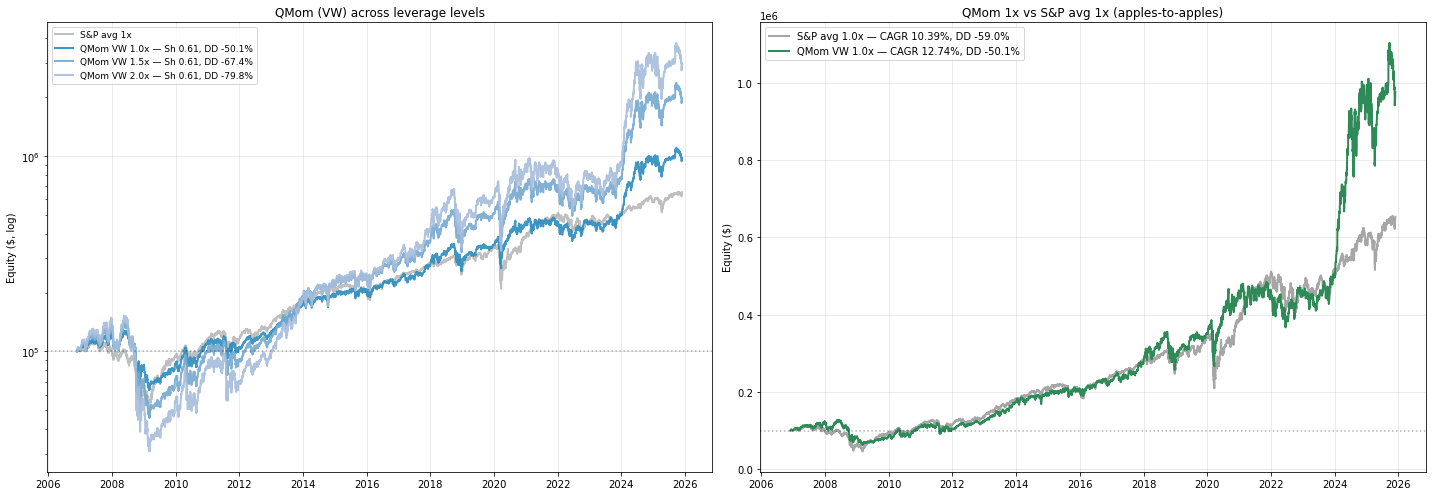

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

ax = axes[0]
ax.plot(spy_results[0]["daily_equity"].index.to_numpy(),
        spy_results[0]["daily_equity"].values,
        color="gray", alpha=0.5, linewidth=2, label=f"S&P avg 1x")
colors_qm = ["#2b8cbe", "#74a9cf", "#a6bddb", "#045a8d"]
for r, c in zip(qm_results, colors_qm):
    s = r["stats"]
    ax.plot(r["daily_equity"].index.to_numpy(), r["daily_equity"].values,
            color=c, linewidth=2, alpha=0.9,
            label=f"{r['label']} — Sh {s['sharpe']}, DD {s['max_dd']}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_yscale("log")
ax.set_title(f"QMom ({winner.upper()}) across leverage levels")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($, log)")

# Right: matched-DD comparison — QMom 1x vs SPY 1x (most apples-to-apples)
ax = axes[1]
q1 = qm_results[0]  # 1x
s1 = spy_results[0]  # 1x
ax.plot(s1["daily_equity"].index.to_numpy(), s1["daily_equity"].values,
        color="gray", linewidth=2, alpha=0.7,
        label=f"{s1['label']} — CAGR {s1['stats']['cagr']}%, DD {s1['stats']['max_dd']}%")
ax.plot(q1["daily_equity"].index.to_numpy(), q1["daily_equity"].values,
        color="seagreen", linewidth=2,
        label=f"{q1['label']} — CAGR {q1['stats']['cagr']}%, DD {q1['stats']['max_dd']}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title(f"QMom 1x vs S&P avg 1x (apples-to-apples)")
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($)")

plt.tight_layout(); plt.show()

## 6. Save

In [8]:
def _key(label):
    return (label.lower().replace(" ", "_").replace(".", "p")
             .replace("&", "and").replace("/", "_"))

os.makedirs("results", exist_ok=True)

all_results = qm_results + spy_results

impl_summary = {}
for r in all_results:
    k = _key(r["label"])
    impl_summary[k] = dict(r["stats"])
    impl_summary[k]["label"] = r["label"]

impl_summary["_matched_dd_edges"] = matched_dd_edges

# Best by Sharpe among QMom results
best = max(qm_results, key=lambda r: r["stats"]["sharpe"])
impl_summary["_recommended"] = best["label"]
print(f"Best by Sharpe: {best['label']} — Sh {best['stats']['sharpe']}, "
      f"DD {best['stats']['max_dd']}%, CAGR {best['stats']['cagr']}%")

# Best by matched-DD edge
best_edge_label = max(matched_dd_edges, key=lambda k: matched_dd_edges[k]["cagr_edge"])
best_edge = matched_dd_edges[best_edge_label]
impl_summary["_best_matched_dd_edge"] = best_edge_label
print(f"\nBest matched-DD edge: {best_edge_label} vs {best_edge['matched_to']}")
print(f"  At DD ~{best_edge['qm_dd']:.1f}%: QMom CAGR {best_edge['qm_cagr']:.2f}% "
      f"vs SPY {best_edge['spy_cagr']:.2f}% (+{best_edge['cagr_edge']:.2f}pp)")

with open(f"results/{SAVE_NAME}_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved → results/{SAVE_NAME}_implementations.json")

# Save equity curves
eq_dir = f"results/{SAVE_NAME}_daily_equity"
os.makedirs(eq_dir, exist_ok=True)
for r in all_results:
    r["daily_equity"].to_csv(f"{eq_dir}/{_key(r['label'])}.csv")
print(f"Saved {len(all_results)} daily equity curves → {eq_dir}/")

Best by Sharpe: QMom VW 1.0x — Sh 0.61, DD -50.1%, CAGR 12.74%

Best matched-DD edge: QMom VW 1.5x vs S&P avg 1.0x
  At DD ~-67.4%: QMom CAGR 16.98% vs SPY 10.39% (+6.59pp)

Saved → results/quantitative_momentum_implementations.json
Saved 6 daily equity curves → results/quantitative_momentum_daily_equity/
